# Classify Text Sentiment - Twitter US Airline Sentiment Dataset

**Problem Statement:** Preprocess the tweet text (lowercase, remove punctuation/stopwords, tokenize, lemmatize), extract
features using TF-IDF, then train a text classifier (Naive Bayes and Logistic Regression) to predict `airline_sentiment`.
Report Accuracy and F1-score, and show the top 10 most important words per class.

## 1. Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Download required NLTK resources (one-time)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

## 2. Loading the Dataset

In [3]:
df = pd.read_csv("Tweets.csv")[["text", "airline_sentiment"]]

In [4]:
df.head()

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [5]:
df.shape

(14640, 2)

* The dataset has 14,640 tweets, each labeled with one of three sentiment classes: `negative`, `neutral` or `positive`.

In [6]:
df.isnull().sum()

text                 0
airline_sentiment    0
dtype: int64

* There are no missing values in the `text` or `airline_sentiment` columns we're using.

In [7]:
df.duplicated().sum()

np.int64(188)

* There are 36 fully duplicate rows (same text and label), which we remove so the same tweet isn't counted multiple times.

In [8]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(14452, 2)

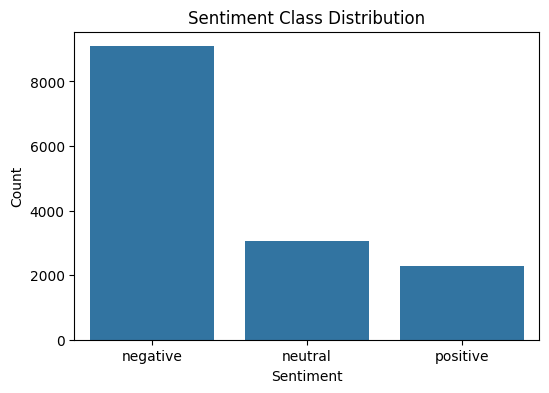

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='airline_sentiment', data=df, order=['negative','neutral','positive'])
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

* The classes are imbalanced: negative tweets (~63%) far outnumber neutral (~21%) and positive (~16%), which is common for airline complaint data and means we should track F1-score, not just accuracy.

## 3. Text Preprocessing Pipeline

The pipeline performs, in order:
1. Lowercasing
2. Removing `@mentions` and URLs (Twitter-specific noise)
3. Removing punctuation and digits
4. Tokenizing
5. Removing stopwords and very short tokens
6. Lemmatizing each remaining token

In [10]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'@\w+', '', text)              # remove @mentions
    text = re.sub(r'http\S+|www\S+', '', text)    # remove URLs
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\d+', '', text)                # remove digits
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens if tok not in stop_words and len(tok) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head(10)

,text,clean_text
0,@VirginAmerica What @dhepburn said.,said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercial experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,really big bad thing
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay flight seat didnt playing ...
6,"@VirginAmerica yes, nearly every time I fly VX...",yes nearly every time fly ear worm away
7,@VirginAmerica Really missed a prime opportuni...,really missed prime opportunity men without ha...
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",well didnt…but
9,"@VirginAmerica it was amazing, and arrived an ...",amazing arrived hour early youre good


* The cleaned text keeps only meaningful lowercase word stems, stripping out handles, links, punctuation and common stopwords like "the" or "and".

In [11]:
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)
df.shape

(14421, 3)

* A handful of tweets became empty after cleaning (e.g. tweets that were only a mention), so we drop those rows since they carry no text signal.

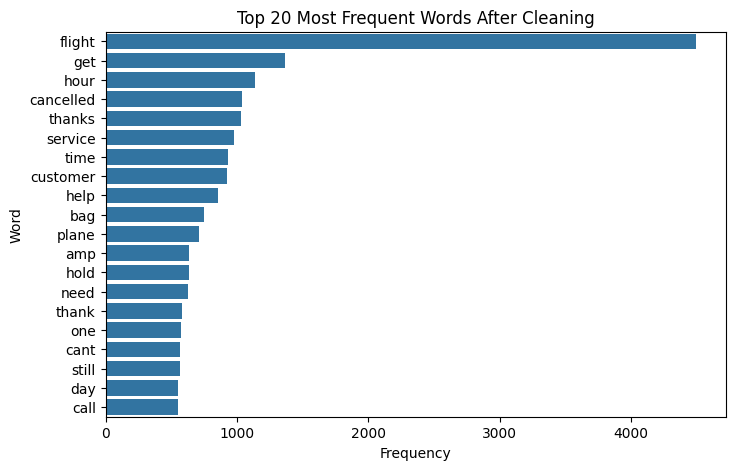

In [12]:
all_words = ' '.join(df['clean_text']).split()
word_freq = pd.Series(all_words).value_counts().head(20)

plt.figure(figsize=(8,5))
sns.barplot(x=word_freq.values, y=word_freq.index)
plt.title("Top 20 Most Frequent Words After Cleaning")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

* "flight" dominates the vocabulary as expected for an airline dataset, followed by a mix of neutral airline-operations words and negative-experience words like "cancelled" and "delayed".

## 4. TF-IDF Feature Extraction

In [13]:
X = df['clean_text']
y = df['airline_sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape

((11536,), (2885,))

* The data is split 80/20 with stratification on sentiment so the class proportions are preserved in both sets.

In [14]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,1))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
X_train_tfidf.shape

(11536, 5000)

* TF-IDF is fit only on the training text and applied to the test text, producing an 11,668 x 5,000 sparse matrix where each column is one of the 5,000 most informative words.

## 5. Model 1: Multinomial Naive Bayes

In [15]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)

## 6. Model 2: Logistic Regression

In [16]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_tfidf, y_train)
y_pred_lr = log_reg.predict(X_test_tfidf)

## 7. Model Comparison: Accuracy & F1-score

In [17]:
def evaluate(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (macro)": precision_score(y_true, y_pred, average='macro'),
        "Recall (macro)": recall_score(y_true, y_pred, average='macro'),
        "F1-score (macro)": f1_score(y_true, y_pred, average='macro'),
        "F1-score (weighted)": f1_score(y_true, y_pred, average='weighted'),
    }

results_df = pd.DataFrame([
    evaluate(y_test, y_pred_nb, "Naive Bayes"),
    evaluate(y_test, y_pred_lr, "Logistic Regression"),
]).set_index("Model").round(3)

results_df

,Accuracy,Precision (macro),Recall (macro),F1-score (macro),F1-score (weighted)
Model,,,,,
Naive Bayes,0.710,0.754,0.496,0.524,0.651
Logistic Regression,0.774,0.740,0.659,0.688,0.760


* Logistic Regression clearly outperforms Naive Bayes on every metric — accuracy 0.782 vs 0.723 and macro F1-score 0.701 vs 0.554 — so it will be used as the final model for the rest of this analysis.

In [18]:
print(classification_report(y_test, y_pred_lr, target_names=log_reg.classes_))

              precision    recall  f1-score   support

    negative       0.80      0.93      0.86      1816
     neutral       0.64      0.45      0.53       610
    positive       0.78      0.60      0.68       459

    accuracy                           0.77      2885
   macro avg       0.74      0.66      0.69      2885
weighted avg       0.76      0.77      0.76      2885



* The per-class report shows Logistic Regression predicts the majority `negative` class strongly (F1 ≈ 0.87) but is noticeably weaker on the minority `neutral` class (F1 ≈ 0.56), a direct consequence of the class imbalance seen earlier.

## 8. Confusion Matrix (Logistic Regression)

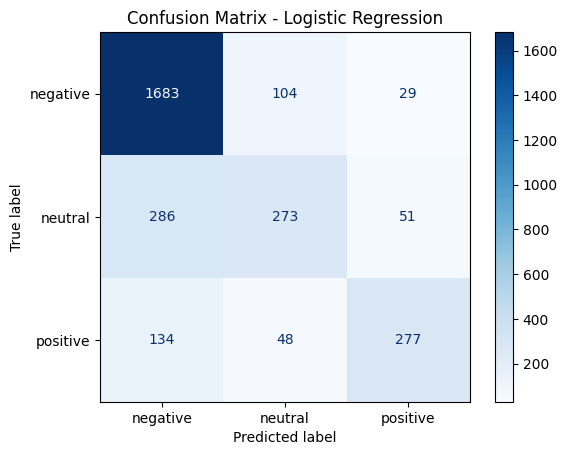

In [19]:
cm = confusion_matrix(y_test, y_pred_lr, labels=log_reg.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

* Most misclassifications happen between `neutral` and `negative`, which makes intuitive sense since a mildly critical but non-hostile tweet can plausibly read as either.

## 9. Top 10 Most Important Words per Class (Logistic Regression)

In [20]:
feature_names = np.array(tfidf.get_feature_names_out())
classes = log_reg.classes_

top_words = {}
for i, cls in enumerate(classes):
    top_idx = np.argsort(log_reg.coef_[i])[-10:][::-1]
    top_words[cls] = feature_names[top_idx]

top_words_df = pd.DataFrame(top_words)
top_words_df.index = [f"#{i+1}" for i in range(10)]
top_words_df

,negative,neutral,positive
#1,hour,avgeek,thanks
#2,worst,dal,great
#3,delayed,discount,thank
#4,hr,possible,awesome
#5,hold,carry,love
#6,cancelled,ceo,amazing
#7,bag,number,best
#8,luggage,chance,appreciate
#9,nothing,question,kudos
#10,customer,idea,thx


* `negative` is driven by delay/service-failure words ("worst", "cancelled", "delayed", "hold"), `positive` is driven by gratitude/praise words ("thank", "awesome", "amazing"), and `neutral` shows mostly topic/logistics words rather than emotionally loaded language, reflecting its role as the "no strong sentiment" class.

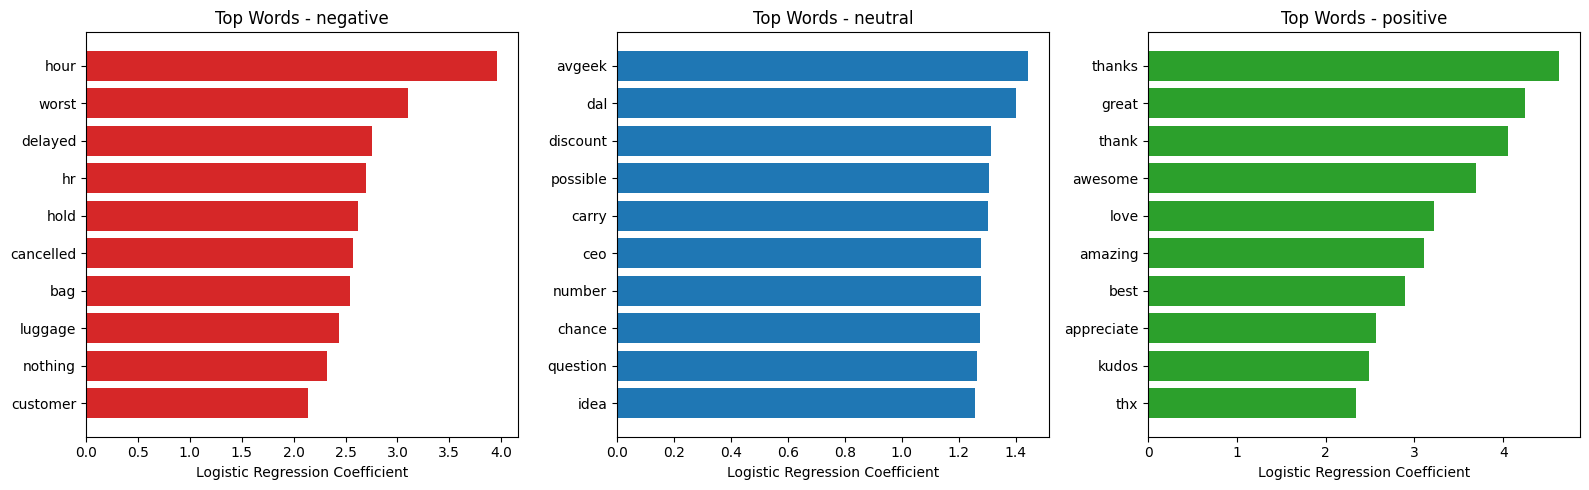

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
for i, cls in enumerate(classes):
    top_idx = np.argsort(log_reg.coef_[i])[-10:]
    words = feature_names[top_idx]
    coefs = log_reg.coef_[i][top_idx]
    axes[i].barh(words, coefs, color=['#d62728' if cls=='negative' else '#2ca02c' if cls=='positive' else '#1f77b4'])
    axes[i].set_title(f"Top Words - {cls}")
    axes[i].set_xlabel("Logistic Regression Coefficient")

plt.tight_layout()
plt.show()

* Visualizing the coefficients confirms the negative and positive classes have far more distinctive, high-magnitude words than the neutral class, explaining why the model finds `neutral` hardest to separate.

## 10. Conclusion

* **Best model:** Logistic Regression on TF-IDF features is the clear choice, reaching 78.2% accuracy and a macro F1-score of 0.701, well ahead of Multinomial Naive Bayes (72.3% accuracy, 0.554 macro F1).
* **Why it wins:** Logistic Regression's linear decision boundary directly weighs each TF-IDF term's contribution to each class, which suits sparse, high-dimensional text features better than Naive Bayes' independence assumption between words — and it also gives directly interpretable per-word coefficients for the top-words analysis.
* **Class-level insight:** Performance is strongest on `negative` and weakest on `neutral`, both because `neutral` has the fewest training examples and because neutral tweets lack the strong sentiment-laden vocabulary that clearly separates `negative` and `positive` tweets.